# NFL 4th Down — The Situational Guide
What SHOULD coaches do in every common 4th down situation, and which situations
are most consistently mismanaged? This is the "cheat sheet" section of the article.

**Central questions:**
- What is the historically optimal 4th down call by field position and distance?
- Where do coaches make the most mistakes?
- How much collective WPA is the NFL leaving on the table — and is it shrinking?

**Inputs:** `data/fourth_downs_graded.parquet`  
**Outputs:** four charts in `outputs/figures/`, `outputs/situational_guide.csv`

In [1]:
import sys
sys.path.append('../src')

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

DATA_DIR = '../data/'
SAVE_DIR = '../outputs/figures/'
OUT_DIR  = '../outputs/'
os.makedirs(SAVE_DIR, exist_ok=True)

FIELD_ORDER  = ['red_zone', 'opp_territory', 'midfield', 'own_territory', 'deep_own']
YDSTOGO_ORDER = ['short_1', 'short_2_3', 'medium_4_6', 'long_7plus']

# Human-readable axis labels
FIELD_LABELS  = ['Red Zone\n(0–20)', 'Opp Territory\n(20–40)', 'Midfield\n(40–60)',
                 'Own Territory\n(60–80)', 'Deep Own\n(80–100)']
YDSTOGO_LABELS = ['4th & 1', '4th & 2–3', '4th & 4–6', '4th & 7+']

DECISION_COLORS = {'go_for_it': '#2E7D32', 'punt': '#7B1FA2', 'field_goal': '#1565C0'}
DECISION_LABELS = {'go_for_it': 'Go For It', 'punt': 'Punt', 'field_goal': 'Field Goal'}
MIN_N = 50   # minimum plays per cell for reliable stats

## 1. Load Data

In [2]:
df = pd.read_parquet(DATA_DIR + 'fourth_downs_graded.parquet')
graded = df.dropna(subset=['decision_gap', 'optimal_decision']).copy()

print(f'Full dataset:  {len(df):,} plays')
print(f'Graded plays:  {len(graded):,}')
print(f'Seasons:       {graded["season"].min()}–{graded["season"].max()}')
print(f'\nField pos bins:  {graded["field_pos_bin"].value_counts().to_dict()}')
print(f'YdsTogo bins:    {graded["ydstogo_bin"].value_counts().to_dict()}')

Full dataset:  107,189 plays
Graded plays:  105,544
Seasons:       1999–2025

Field pos bins:  {'own_territory': 32130, 'midfield': 26193, 'opp_territory': 19629, 'red_zone': 17395, 'deep_own': 10197}
YdsTogo bins:    {'long_7plus': 54058, 'medium_4_6': 23922, 'short_2_3': 15961, 'short_1': 11603}


## 2. Field Position × Yards-to-Go Grid
Core 5×4 grid aggregating all plays into 20 situational cells.

In [3]:
def cell_stats(sub):
    """Compute summary stats for a group of plays in one situational cell."""
    n           = len(sub)
    go_actual   = (sub['decision'] == 'go_for_it').mean()
    punt_actual = (sub['decision'] == 'punt').mean()
    fg_actual   = (sub['decision'] == 'field_goal').mean()
    go_optimal  = (sub['optimal_decision'] == 'go_for_it').mean()
    wrong_rate  = (sub['decision'] != sub['optimal_decision']).mean()
    mean_gap    = sub['decision_gap'].mean()
    # Most common optimal decision in this cell
    opt_decision = sub['optimal_decision'].mode().iloc[0]
    return pd.Series({
        'n':              n,
        'optimal_decision': opt_decision,
        'go_pct_actual':  go_actual,
        'punt_pct_actual':punt_actual,
        'fg_pct_actual':  fg_actual,
        'go_pct_optimal': go_optimal,
        'wrong_call_rate':wrong_rate,
        'mean_decision_gap': mean_gap,
    })

grid = (
    graded
    .groupby(['field_pos_bin', 'ydstogo_bin'])
    .apply(cell_stats, include_groups=False)
    .reset_index()
)

# Apply minimum sample filter
grid_reliable = grid[grid['n'] >= MIN_N].copy()
print(f'Grid cells total: {len(grid)}')
print(f'Grid cells with n>={MIN_N}: {len(grid_reliable)}')
print()
print('Full grid (wrong_call_rate):')
print(
    grid_reliable.pivot(
        index='field_pos_bin', columns='ydstogo_bin', values='wrong_call_rate'
    ).reindex(index=FIELD_ORDER, columns=YDSTOGO_ORDER)
    .mul(100).round(1)
    .to_string()
)
print()
print('Optimal decision by cell:')
print(
    grid_reliable.pivot(
        index='field_pos_bin', columns='ydstogo_bin', values='optimal_decision'
    ).reindex(index=FIELD_ORDER, columns=YDSTOGO_ORDER)
    .to_string()
)

Grid cells total: 20
Grid cells with n>=50: 20

Full grid (wrong_call_rate):
ydstogo_bin    short_1  short_2_3  medium_4_6  long_7plus
field_pos_bin                                            
red_zone          31.4       54.9        15.5         6.4
opp_territory     26.5       52.5        52.9        41.8
midfield          48.1       50.9        48.4        54.7
own_territory     52.3       44.6        33.2        14.1
deep_own           0.0        1.7         0.7         1.0

Optimal decision by cell:
ydstogo_bin      short_1  short_2_3  medium_4_6  long_7plus
field_pos_bin                                              
red_zone       go_for_it  go_for_it  field_goal  field_goal
opp_territory  go_for_it  go_for_it   go_for_it  field_goal
midfield       go_for_it  go_for_it   go_for_it   go_for_it
own_territory  go_for_it  go_for_it        punt        punt
deep_own            punt       punt        punt        punt


## 3. Full Game-State Analysis (4-Dimensional)
Drill into the 4D game state (field pos × yds × score × time) to find the
10 most mismanaged specific situations.

In [4]:
full_grid = (
    graded
    .groupby(['field_pos_bin', 'ydstogo_bin', 'score_diff_bin', 'time_bin'])
    .apply(cell_stats, include_groups=False)
    .reset_index()
)

full_reliable = full_grid[full_grid['n'] >= MIN_N].copy()
full_reliable['total_wpa_lost'] = full_reliable['mean_decision_gap'] * full_reliable['n']

print(f'4D game states total:        {len(full_grid)}')
print(f'4D states with n>={MIN_N}:     {len(full_reliable)}')
print()

# Top 10 by wrong_call_rate
top10_wrong = full_reliable.nlargest(10, 'wrong_call_rate')[
    ['field_pos_bin','ydstogo_bin','score_diff_bin','time_bin',
     'n','optimal_decision','wrong_call_rate','mean_decision_gap']
]
print('Top 10 most mismanaged situations (by wrong_call_rate):')
print(
    top10_wrong
    .assign(
        wrong_call_rate   = lambda x: (x['wrong_call_rate']*100).map('{:.1f}%'.format),
        mean_decision_gap = lambda x: x['mean_decision_gap'].map('{:.4f}'.format),
    )
    .to_string(index=False)
)

print()
# Top 10 by total WPA lost (high volume × high wrong rate)
top10_wpa = full_reliable.nlargest(10, 'total_wpa_lost')[
    ['field_pos_bin','ydstogo_bin','score_diff_bin','time_bin',
     'n','optimal_decision','wrong_call_rate','mean_decision_gap','total_wpa_lost']
]
print('Top 10 situations by total WPA lost (volume × gap):')
print(
    top10_wpa
    .assign(
        wrong_call_rate   = lambda x: (x['wrong_call_rate']*100).map('{:.1f}%'.format),
        mean_decision_gap = lambda x: x['mean_decision_gap'].map('{:.4f}'.format),
        total_wpa_lost    = lambda x: x['total_wpa_lost'].map('{:.2f}'.format),
    )
    .to_string(index=False)
)

4D game states total:        656
4D states with n>=50:     437

Top 10 most mismanaged situations (by wrong_call_rate):
field_pos_bin ydstogo_bin score_diff_bin    time_bin    n optimal_decision wrong_call_rate mean_decision_gap
     midfield  long_7plus down_one_score  early_game 1161       field_goal           99.1%            0.0571
own_territory  medium_4_6           tied  early_game 1328        go_for_it           99.1%            0.0849
     midfield  long_7plus           tied  early_game 2193        go_for_it           98.9%            0.0262
own_territory  long_7plus       down_big second_half 1224        go_for_it           98.9%            0.0246
own_territory   short_2_3           tied  early_game  832        go_for_it           98.7%            0.0145
own_territory  medium_4_6 down_one_score  early_game  687        go_for_it           98.4%            0.0212
     midfield  long_7plus   up_one_score  early_game  642        go_for_it           98.0%            0.0186
     mid

## 4. Wrong-Call Breakdown by Decision Type
Which type of mistake is most costly — punting when you should go, or kicking a FG when you should go?

In [5]:
wrong_plays = graded[graded['decision'] != graded['optimal_decision']].copy()
wrong_plays['mistake_type'] = wrong_plays['decision'] + ' (should be ' + wrong_plays['optimal_decision'] + ')'

mistake_summary = (
    wrong_plays
    .groupby('mistake_type')
    .agg(
        n           = ('decision_gap', 'count'),
        mean_gap    = ('decision_gap', 'mean'),
        total_gap   = ('decision_gap', 'sum'),
    )
    .sort_values('total_gap', ascending=False)
    .reset_index()
)
mistake_summary['pct_of_mistakes'] = mistake_summary['n'] / mistake_summary['n'].sum() * 100

print('Wrong-call breakdown (all seasons):')
print(
    mistake_summary
    .assign(
        mean_gap  = lambda x: x['mean_gap'].map('{:.4f}'.format),
        total_gap = lambda x: x['total_gap'].map('{:.2f}'.format),
        pct_of_mistakes = lambda x: x['pct_of_mistakes'].map('{:.1f}%'.format),
    )
    .to_string(index=False)
)

Wrong-call breakdown (all seasons):
                    mistake_type     n mean_gap total_gap pct_of_mistakes
      punt (should be go_for_it) 21576   0.0278    600.43           61.9%
field_goal (should be go_for_it)  7837   0.0190    149.15           22.5%
     punt (should be field_goal)  2887   0.0392    113.04            8.3%
go_for_it (should be field_goal)  1919   0.0158     30.27            5.5%
     field_goal (should be punt)   261   0.0097      2.53            0.7%
      go_for_it (should be punt)   400   0.0056      2.26            1.1%


## 5. Recoverable WPA
How much WPA could teams gain each season if every coach made the optimal call?

In [6]:
total_wrong_plays = len(graded[graded['decision'] != graded['optimal_decision']])
total_plays       = len(graded)
total_gap_all     = graded['decision_gap'].sum()
avg_seasons       = graded['season'].nunique()
recoverable_per_season = total_gap_all / avg_seasons
per_team_per_season    = recoverable_per_season / 32

# By era
def era_label(s):
    return 'Traditional' if s <= 2018 else 'Analytics'

graded['era'] = graded['season'].apply(era_label)
era_recoverable = (
    graded
    .groupby('era')
    .agg(
        total_gap   = ('decision_gap', 'sum'),
        n_seasons   = ('season', 'nunique'),
        n_plays     = ('decision_gap', 'count'),
    )
    .assign(gap_per_season = lambda x: x['total_gap'] / x['n_seasons'])
    .reindex(['Traditional', 'Analytics'])
)

print('Recoverable WPA summary:')
print(f'  Total suboptimal plays:         {total_wrong_plays:,} of {total_plays:,} ({total_wrong_plays/total_plays*100:.1f}%)')
print(f'  Total WPA left on table (all):  {total_gap_all:.1f} WPA')
print(f'  Per season (league-wide avg):   {recoverable_per_season:.1f} WPA')
print(f'  Per team per season (avg):      {per_team_per_season:.2f} WPA')
print()
print('By era:')
print(
    era_recoverable
    .assign(
        total_gap       = lambda x: x['total_gap'].map('{:.1f}'.format),
        gap_per_season  = lambda x: x['gap_per_season'].map('{:.1f}'.format),
    )
    .to_string()
)

Recoverable WPA summary:
  Total suboptimal plays:         34,880 of 105,544 (33.0%)
  Total WPA left on table (all):  897.7 WPA
  Per season (league-wide avg):   33.2 WPA
  Per team per season (avg):      1.04 WPA

By era:
            total_gap  n_seasons  n_plays gap_per_season
era                                                     
Traditional     699.4         20    78407           35.0
Analytics       198.3          7    27137           28.3


## 6. Chart 19 — The 4th Down Decision Guide
Clean heatmap showing the optimal call for each field position × yards-to-go combination.
The "cheat sheet" — designed to be clean enough to screenshot and share.

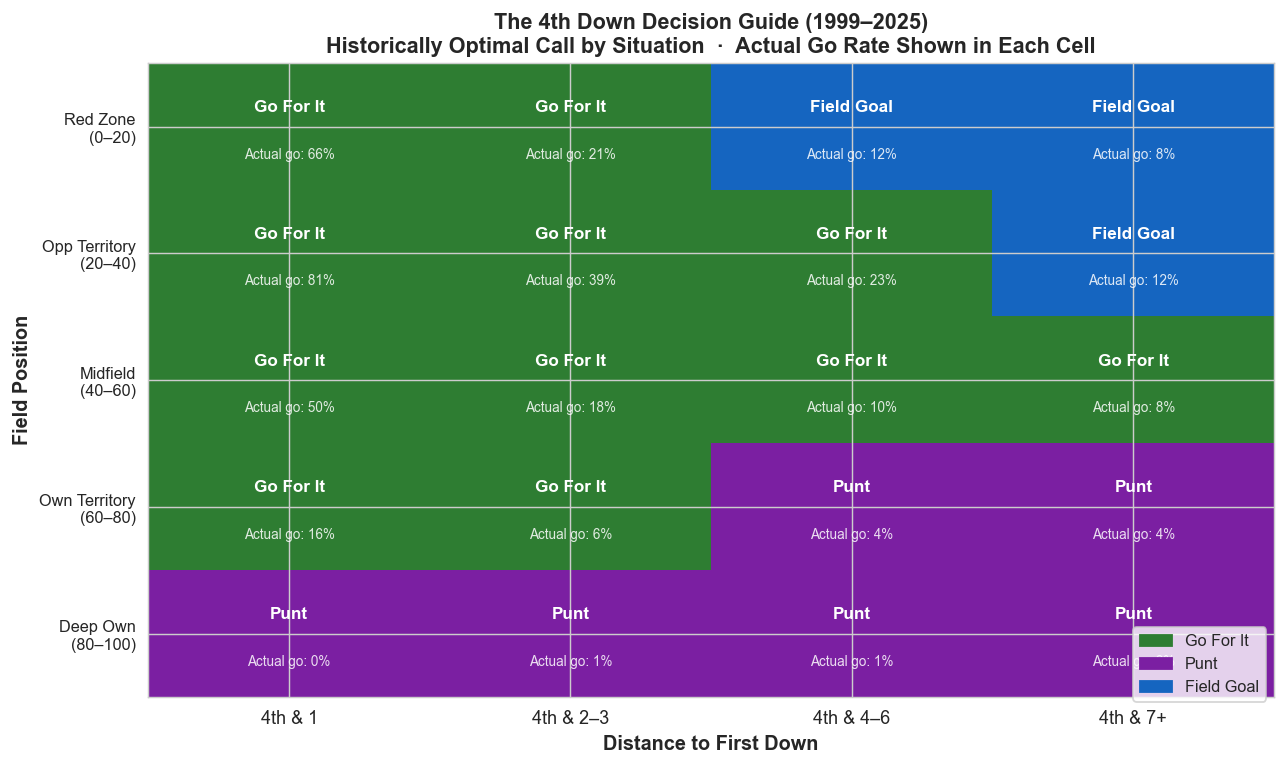

Saved: 19_optimal_decision_guide.png


In [7]:
# Build pivot tables for the heatmap
opt_pivot   = grid_reliable.pivot(index='field_pos_bin', columns='ydstogo_bin', values='optimal_decision').reindex(index=FIELD_ORDER, columns=YDSTOGO_ORDER)
go_act_piv  = grid_reliable.pivot(index='field_pos_bin', columns='ydstogo_bin', values='go_pct_actual').reindex(index=FIELD_ORDER, columns=YDSTOGO_ORDER)
go_opt_piv  = grid_reliable.pivot(index='field_pos_bin', columns='ydstogo_bin', values='go_pct_optimal').reindex(index=FIELD_ORDER, columns=YDSTOGO_ORDER)
n_piv       = grid_reliable.pivot(index='field_pos_bin', columns='ydstogo_bin', values='n').reindex(index=FIELD_ORDER, columns=YDSTOGO_ORDER)

# Encode optimal decision as a numeric value for coloring
DECISION_NUM = {'go_for_it': 0, 'field_goal': 1, 'punt': 2}
num_pivot = opt_pivot.map(lambda x: DECISION_NUM.get(x, np.nan) if pd.notna(x) else np.nan)

from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#2E7D32', '#1565C0', '#7B1FA2'])  # go, FG, punt

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(num_pivot.values, cmap=cmap, vmin=-0.5, vmax=2.5, aspect='auto')

# Cell text: decision label + actual go rate
for row_i, fp in enumerate(FIELD_ORDER):
    for col_i, yd in enumerate(YDSTOGO_ORDER):
        opt = opt_pivot.loc[fp, yd] if fp in opt_pivot.index and yd in opt_pivot.columns else None
        go_act = go_act_piv.loc[fp, yd] if fp in go_act_piv.index else np.nan
        go_opt = go_opt_piv.loc[fp, yd] if fp in go_opt_piv.index else np.nan
        n_val  = n_piv.loc[fp, yd] if fp in n_piv.index else np.nan

        if pd.isna(opt) or pd.isna(n_val):
            ax.text(col_i, row_i, 'n/a', ha='center', va='center', fontsize=9, color='grey')
            continue

        label = DECISION_LABELS.get(opt, opt)
        line2 = f'Actual go: {go_act*100:.0f}%' if not pd.isna(go_act) else ''

        ax.text(col_i, row_i - 0.15, label,
                ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')
        ax.text(col_i, row_i + 0.22, line2,
                ha='center', va='center', fontsize=7.5, color='white', alpha=0.85)

ax.set_xticks(range(len(YDSTOGO_ORDER)))
ax.set_xticklabels(YDSTOGO_LABELS, fontsize=10)
ax.set_yticks(range(len(FIELD_ORDER)))
ax.set_yticklabels(FIELD_LABELS, fontsize=9)
ax.set_xlabel('Distance to First Down', fontsize=11, fontweight='bold')
ax.set_ylabel('Field Position', fontsize=11, fontweight='bold')
ax.set_title(
    'The 4th Down Decision Guide (1999–2025)\nHistorically Optimal Call by Situation  ·  Actual Go Rate Shown in Each Cell',
    fontsize=12, fontweight='bold'
)

# Legend
patches = [mpatches.Patch(color=c, label=DECISION_LABELS[d])
           for d, c in DECISION_COLORS.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9,
          bbox_to_anchor=(1.0, -0.02))

plt.tight_layout()
plt.savefig(SAVE_DIR + '19_optimal_decision_guide.png', bbox_inches='tight')
plt.show()
print('Saved: 19_optimal_decision_guide.png')

## 7. Chart 20 — Where Coaches Make the Most Mistakes
Same grid, colored by wrong-call rate. White = coaches almost always get it right.
Dark red = coaches regularly make the wrong call.

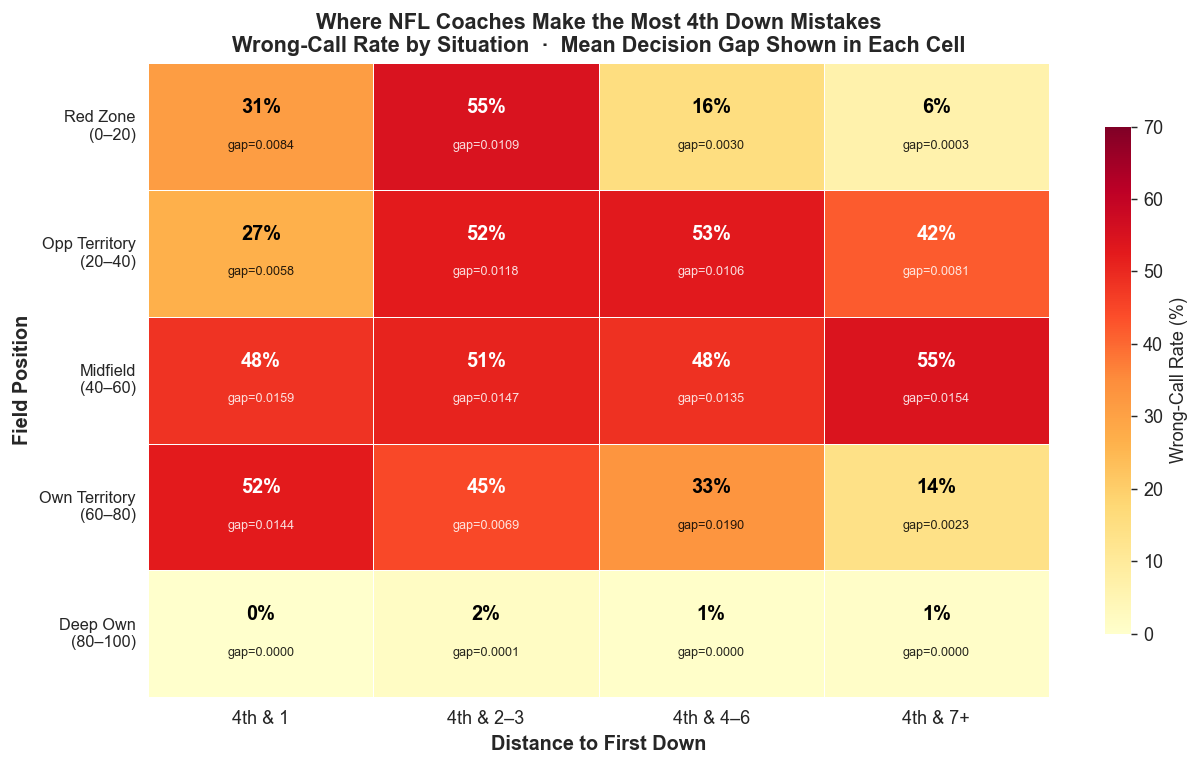

Saved: 20_wrong_call_heatmap.png


In [8]:
wrong_piv = grid_reliable.pivot(
    index='field_pos_bin', columns='ydstogo_bin', values='wrong_call_rate'
).reindex(index=FIELD_ORDER, columns=YDSTOGO_ORDER)

gap_piv = grid_reliable.pivot(
    index='field_pos_bin', columns='ydstogo_bin', values='mean_decision_gap'
).reindex(index=FIELD_ORDER, columns=YDSTOGO_ORDER)

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    wrong_piv * 100,
    ax=ax,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Wrong-Call Rate (%)', 'shrink': 0.8},
    vmin=0, vmax=70
)

# Annotate each cell with wrong rate + mean gap
for row_i, fp in enumerate(FIELD_ORDER):
    for col_i, yd in enumerate(YDSTOGO_ORDER):
        wr  = wrong_piv.loc[fp, yd] if fp in wrong_piv.index and yd in wrong_piv.columns else np.nan
        gap = gap_piv.loc[fp, yd]   if fp in gap_piv.index   and yd in gap_piv.columns   else np.nan

        if pd.isna(wr):
            ax.text(col_i + 0.5, row_i + 0.5, 'n/a',
                    ha='center', va='center', fontsize=9, color='grey')
            continue

        text_color = 'white' if wr > 0.40 else 'black'
        ax.text(col_i + 0.5, row_i + 0.35, f'{wr*100:.0f}%',
                ha='center', va='center', fontsize=11, color=text_color, fontweight='bold')
        ax.text(col_i + 0.5, row_i + 0.65, f'gap={gap:.4f}',
                ha='center', va='center', fontsize=7, color=text_color, alpha=0.85)

ax.set_xticklabels(YDSTOGO_LABELS, fontsize=10)
ax.set_yticklabels(FIELD_LABELS, fontsize=9, rotation=0)
ax.set_xlabel('Distance to First Down', fontsize=11, fontweight='bold')
ax.set_ylabel('Field Position', fontsize=11, fontweight='bold')
ax.set_title(
    'Where NFL Coaches Make the Most 4th Down Mistakes\nWrong-Call Rate by Situation  ·  Mean Decision Gap Shown in Each Cell',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig(SAVE_DIR + '20_wrong_call_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: 20_wrong_call_heatmap.png')

## 8. Chart 21 — Top 10 Most Mismanaged Situations
Specific 4-dimensional game states with the highest wrong-call rate.

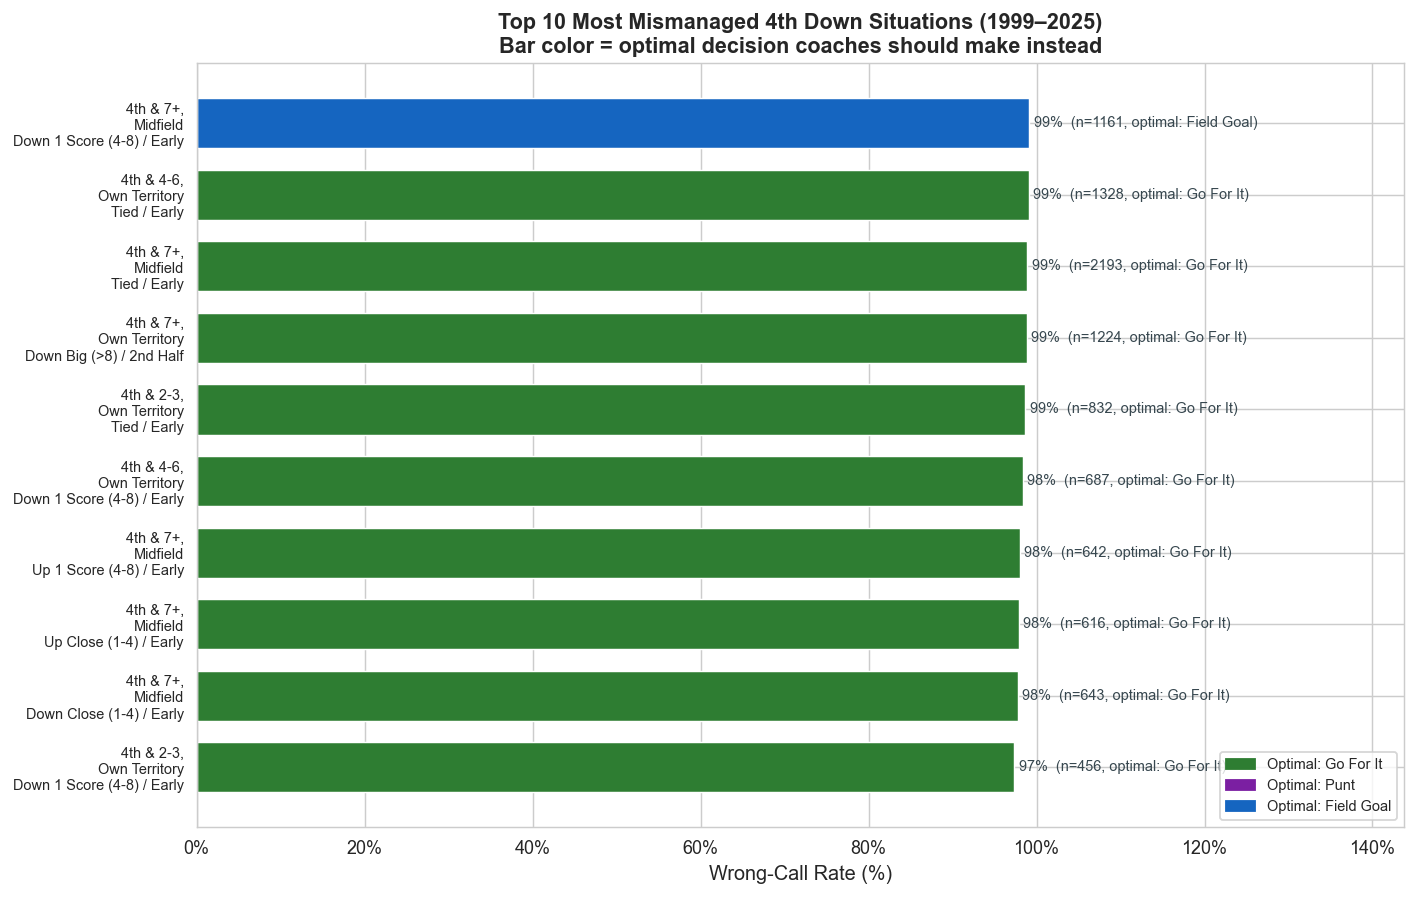

Saved: 21_top10_mismanaged.png


In [9]:
# Create readable situation labels
FIELD_SHORT  = {'red_zone':'Red Zone','opp_territory':'Opp Territory',
                'midfield':'Midfield','own_territory':'Own Territory','deep_own':'Deep Own'}
YDS_SHORT    = {'short_1':'4th & 1','short_2_3':'4th & 2-3',
                'medium_4_6':'4th & 4-6','long_7plus':'4th & 7+'}
SCORE_SHORT  = {'down_big':'Down Big (>8)','down_one_score':'Down 1 Score (4-8)',
                'down_close':'Down Close (1-4)','tied':'Tied',
                'up_close':'Up Close (1-4)','up_one_score':'Up 1 Score (4-8)',
                'up_big':'Up Big (>8)'}
TIME_SHORT   = {'two_min_drill':'2-Min Drill','late_4th':'Late 4th',
                '4th_quarter':'4th Quarter','second_half':'2nd Half','early_game':'Early'}

top10 = full_reliable.nlargest(10, 'wrong_call_rate').copy()
top10['situation'] = (
    top10['ydstogo_bin'].astype(str).map(YDS_SHORT) + ',\n' +
    top10['field_pos_bin'].astype(str).map(FIELD_SHORT) + '\n' +
    top10['score_diff_bin'].astype(str).map(SCORE_SHORT) + ' / ' +
    top10['time_bin'].astype(str).map(TIME_SHORT)
)

fig, ax = plt.subplots(figsize=(11, 7))

bar_colors = [
    DECISION_COLORS.get(opt, '#546E7A')
    for opt in top10['optimal_decision']
]

bars = ax.barh(
    range(len(top10)),
    top10['wrong_call_rate'] * 100,
    color=bar_colors, edgecolor='white', linewidth=0.8, height=0.7
)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10['situation'].tolist(), fontsize=8)
ax.invert_yaxis()

# Annotate each bar
for bar, (_, row) in zip(bars, top10.iterrows()):
    w = bar.get_width()
    opt_label = DECISION_LABELS.get(row['optimal_decision'], row['optimal_decision'])
    ax.text(
        w + 0.5, bar.get_y() + bar.get_height() / 2,
        f"{w:.0f}%  (n={int(row['n'])}, optimal: {opt_label})",
        va='center', fontsize=8, color='#37474F'
    )

ax.set_xlabel('Wrong-Call Rate (%)', fontsize=11)
ax.set_xlim(0, top10['wrong_call_rate'].max() * 100 * 1.45)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# Decision color legend
patches = [mpatches.Patch(color=c, label=f'Optimal: {DECISION_LABELS[d]}')
           for d, c in DECISION_COLORS.items()]
ax.legend(handles=patches, fontsize=8, loc='lower right')

ax.set_title(
    'Top 10 Most Mismanaged 4th Down Situations (1999–2025)\nBar color = optimal decision coaches should make instead',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig(SAVE_DIR + '21_top10_mismanaged.png', bbox_inches='tight')
plt.show()
print('Saved: 21_top10_mismanaged.png')

## 9. Chart 22 — WPA Left on the Table by Era
League-wide recoverable WPA per season — is this gap shrinking in the Analytics era?

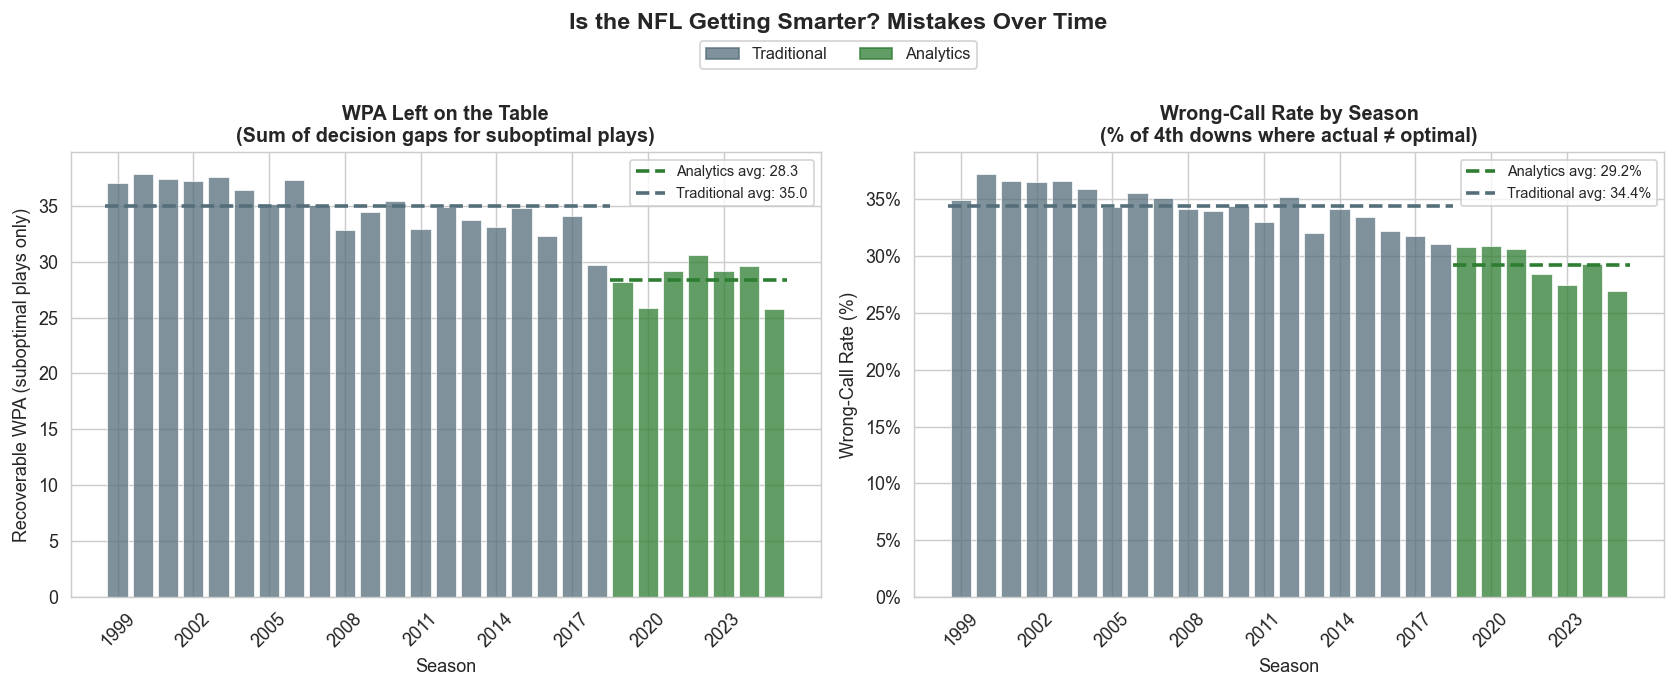

Saved: 22_recoverable_wpa.png


In [10]:
by_season_gap = (
    graded
    .groupby('season')
    .agg(
        wrong_plays  = ('made_optimal', lambda x: (x == 0).sum()),
        total_plays  = ('made_optimal', 'count'),
        total_gap    = ('decision_gap', 'sum'),
        recoverable  = ('decision_gap', lambda x: x[x > 0].sum()),
    )
    .reset_index()
)
by_season_gap['wrong_rate'] = by_season_gap['wrong_plays'] / by_season_gap['total_plays']
by_season_gap['era'] = by_season_gap['season'].apply(era_label)

era_colors = {'Traditional': '#546E7A', 'Analytics': '#2E7D32'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: total recoverable WPA per season ────────────────────────────────────
colors_bar = [era_colors[e] for e in by_season_gap['era']]
ax1.bar(by_season_gap['season'], by_season_gap['recoverable'],
        color=colors_bar, alpha=0.75, edgecolor='white', linewidth=0.5)

# Era average lines
for era, grp in by_season_gap.groupby('era'):
    avg = grp['recoverable'].mean()
    min_s, max_s = grp['season'].min(), grp['season'].max()
    ax1.hlines(avg, min_s - 0.5, max_s + 0.5,
               color=era_colors[era], linewidth=2, linestyle='--',
               label=f'{era} avg: {avg:.1f}')

ax1.set_xlabel('Season', fontsize=10)
ax1.set_ylabel('Recoverable WPA (suboptimal plays only)', fontsize=10)
ax1.set_xticks(range(1999, 2026, 3))
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=8)
ax1.set_title('WPA Left on the Table\n(Sum of decision gaps for suboptimal plays)', fontsize=11, fontweight='bold')

# ── Right: wrong-call rate trend ──────────────────────────────────────────────
ax2.bar(by_season_gap['season'], by_season_gap['wrong_rate'] * 100,
        color=colors_bar, alpha=0.75, edgecolor='white', linewidth=0.5)

for era, grp in by_season_gap.groupby('era'):
    avg = grp['wrong_rate'].mean() * 100
    min_s, max_s = grp['season'].min(), grp['season'].max()
    ax2.hlines(avg, min_s - 0.5, max_s + 0.5,
               color=era_colors[era], linewidth=2, linestyle='--',
               label=f'{era} avg: {avg:.1f}%')

ax2.set_xlabel('Season', fontsize=10)
ax2.set_ylabel('Wrong-Call Rate (%)', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.set_xticks(range(1999, 2026, 3))
ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=8)
ax2.set_title('Wrong-Call Rate by Season\n(% of 4th downs where actual ≠ optimal)', fontsize=11, fontweight='bold')

# Era legend patches
era_patches = [mpatches.Patch(color=c, label=e, alpha=0.75) for e, c in era_colors.items()]
fig.legend(handles=era_patches, loc='upper center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, 1.02))

fig.suptitle('Is the NFL Getting Smarter? Mistakes Over Time', fontsize=13, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig(SAVE_DIR + '22_recoverable_wpa.png', bbox_inches='tight')
plt.show()
print('Saved: 22_recoverable_wpa.png')

## 10. Save situational_guide.csv

In [11]:
situational_guide = grid_reliable[[
    'field_pos_bin', 'ydstogo_bin', 'optimal_decision', 'wrong_call_rate',
    'mean_decision_gap', 'n', 'go_pct_actual', 'go_pct_optimal',
    'punt_pct_actual', 'fg_pct_actual'
]].copy()

situational_guide.to_csv(OUT_DIR + 'situational_guide.csv', index=False)

print('Saved: outputs/situational_guide.csv')
print(f'Rows: {len(situational_guide)}')
print()
print(situational_guide.assign(
    wrong_call_rate   = lambda x: (x['wrong_call_rate']*100).map('{:.1f}%'.format),
    go_pct_actual     = lambda x: (x['go_pct_actual']*100).map('{:.1f}%'.format),
    go_pct_optimal    = lambda x: (x['go_pct_optimal']*100).map('{:.1f}%'.format),
    mean_decision_gap = lambda x: x['mean_decision_gap'].map('{:.4f}'.format),
).to_string(index=False))

Saved: outputs/situational_guide.csv
Rows: 20

field_pos_bin ydstogo_bin optimal_decision wrong_call_rate mean_decision_gap     n go_pct_actual go_pct_optimal  punt_pct_actual  fg_pct_actual
     red_zone     short_1        go_for_it           31.4%            0.0084  2912         65.7%          88.9%         0.000000       0.343407
     red_zone   short_2_3        go_for_it           54.9%            0.0109  3657         20.8%          75.1%         0.000000       0.791632
     red_zone  medium_4_6       field_goal           15.5%            0.0030  4844         11.5%          24.5%         0.000000       0.884600
     red_zone  long_7plus       field_goal            6.4%            0.0003  5982          7.8%           9.0%         0.000000       0.922434
opp_territory     short_1        go_for_it           26.5%            0.0058  2253         80.7%          83.4%         0.007545       0.185530
opp_territory   short_2_3        go_for_it           52.5%            0.0118  3068       

## 11. Summary Findings

In [12]:
most_wrong  = grid_reliable.nlargest(1, 'wrong_call_rate').iloc[0]
least_wrong = grid_reliable.nsmallest(1, 'wrong_call_rate').iloc[0]
biggest_gap = grid_reliable.nlargest(1, 'mean_decision_gap').iloc[0]

trad_gap = era_recoverable.loc['Traditional', 'gap_per_season']
anal_gap = era_recoverable.loc['Analytics',   'gap_per_season']

top_mistake = mistake_summary.iloc[0]

print('=' * 65)
print('SITUATIONAL GUIDE SUMMARY')
print('=' * 65)
print(f'Total plays analyzed: {len(graded):,} (all graded 4th downs)')
print(f'Wrong-call rate overall: {(graded["decision"] != graded["optimal_decision"]).mean()*100:.1f}%')
print()
print('Most mismanaged cell (2D grid):')
print(f'  {most_wrong["field_pos_bin"]} × {most_wrong["ydstogo_bin"]}')
print(f'  Wrong-call rate: {most_wrong["wrong_call_rate"]*100:.1f}%  |  Optimal: {most_wrong["optimal_decision"]}')
print()
print('Most reliable cell (coaches usually get it right):')
print(f'  {least_wrong["field_pos_bin"]} × {least_wrong["ydstogo_bin"]}')
print(f'  Wrong-call rate: {least_wrong["wrong_call_rate"]*100:.1f}%')
print()
print('Most costly mistake type:')
print(f'  {top_mistake["mistake_type"]} — {int(top_mistake["n"]):,} plays, avg gap {top_mistake["mean_gap"]:.4f}')
print()
print('Recoverable WPA per season:')
print(f'  Traditional era avg: {trad_gap:.1f} WPA/season')
print(f'  Analytics era avg:   {anal_gap:.1f} WPA/season')
print(f'  Improvement:         {trad_gap - anal_gap:.1f} WPA/season ({(trad_gap-anal_gap)/trad_gap*100:.0f}% reduction)')
print('=' * 65)

SITUATIONAL GUIDE SUMMARY
Total plays analyzed: 105,544 (all graded 4th downs)
Wrong-call rate overall: 33.0%

Most mismanaged cell (2D grid):
  red_zone × short_2_3
  Wrong-call rate: 54.9%  |  Optimal: go_for_it

Most reliable cell (coaches usually get it right):
  deep_own × short_1
  Wrong-call rate: 0.0%

Most costly mistake type:
  punt (should be go_for_it) — 21,576 plays, avg gap 0.0278

Recoverable WPA per season:
  Traditional era avg: 35.0 WPA/season
  Analytics era avg:   28.3 WPA/season
  Improvement:         6.6 WPA/season (19% reduction)
